# Exercise 10.1c solution


In [1]:
# --- Setup code from previous sub-exercises ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def transition_matrix(k_co, k_oc, k_oi, k_io):
    """Build the 3x3 transition rate matrix for the C-O-I model."""
    # State indices
    C = 0
    O = 1
    I = 2

    n = 3
    A = np.zeros((n, n))

    # Off-diagonal transition rates
    # A[to_state, from_state] = rate
    A[O, C] = k_co  # C -> O
    A[C, O] = k_oc  # O -> C
    A[I, O] = k_oi  # O -> I
    A[O, I] = k_io  # I -> O

    # Diagonal: each column sums to zero
    for i in range(n):
        A[i, i] = -np.sum(A[:, i]) + A[i, i]

    return A


def ode_system(t, y, A):
    """Solve the deterministic ODE"""
    return A @ y


def advance_stochastic(state, A, dt):
    """Advance a single channel by one time step using stochastic simulation.

    Parameters
    ----------
    state : int
        Current state index (0=C, 1=O, 2=I)
    A : ndarray
        Transition rate matrix
    dt : float
        Time step

    Returns
    -------
    int
        New state index
    """

    # Get transition probabilities from current state
    P = A[:, state] * dt

    P[state] = 0  # No self-transition

    # Use cumulative probability to decide transition
    CP = np.cumsum(P)
    r = np.random.rand()
    for i in range(len(CP)):
        if r < CP[i]:
            state = i
            return i

    return state  # No transition


# Set rate constants
k_co = 5
k_oc = 10
k_oi = 1
k_io = 0

A = transition_matrix(k_co, k_oc, k_oi, k_io)

# Deterministic solution for comparison
y0 = np.array([1.0, 0.0, 0.0])  # Start in closed state
dt = 0.01
t_span = (0, 5)
t = np.arange(*t_span, dt)

sol = solve_ivp(ode_system, t_span, y0, t_eval=t, args=(A,))
# ----------------------------------------------

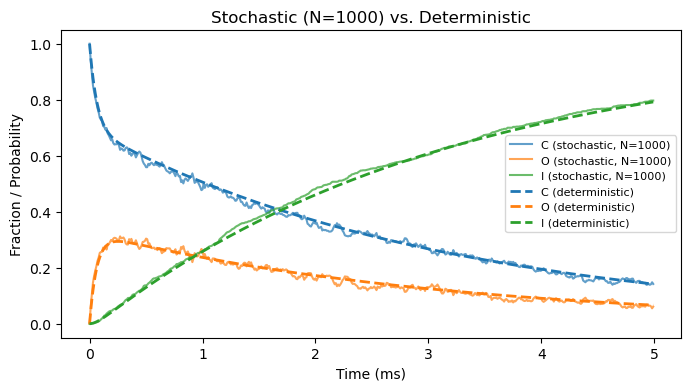

In [2]:
# Stochastic simulation with N channels
N = 1000
S = np.zeros((len(t), N), dtype=int)
for n_ch in range(N):
    S[0, n_ch] = 0
    for i in range(len(t) - 1):
        S[i + 1, n_ch] = advance_stochastic(S[i, n_ch], A, dt)

frac_C = np.mean(S == 0, axis=1)
frac_O = np.mean(S == 1, axis=1)
frac_I = np.mean(S == 2, axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, frac_C, "C0", alpha=0.7, label=f"C (stochastic, N={N})")
ax.plot(t, frac_O, "C1", alpha=0.7, label=f"O (stochastic, N={N})")
ax.plot(t, frac_I, "C2", alpha=0.7, label=f"I (stochastic, N={N})")
ax.plot(sol.t, sol.y[0], "C0--", linewidth=2, label="C (deterministic)")
ax.plot(sol.t, sol.y[1], "C1--", linewidth=2, label="O (deterministic)")
ax.plot(sol.t, sol.y[2], "C2--", linewidth=2, label="I (deterministic)")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Fraction / Probability")
ax.set_title(f"Stochastic (N={N}) vs. Deterministic")
ax.legend(fontsize=8)
plt.show()

**Answers:**

1. The noise level decreases as $1/\sqrt{N}$ (law of large numbers). With $N = 10$ the curves are very noisy; with $N = 1000$ they closely match the deterministic solution.

2. A typical cardiac cell has ~3000 µm² of membrane with ~100 Na⁺ channels per µm², giving approximately **300,000 channels**. At this scale, the stochastic fluctuations are negligible — less than 0.2% of the signal — which is why macroscopic currents are smooth and well-described by the deterministic ODE.
